# Snore vs Non‑Snore with YAMNet + MLP (Noise‑Augmented)

**Colab‑ready notebook** that keeps the data augmentation logic (random ESC‑50 noise at random SNR) the same as your project file and trains a deep learning model for prediction.

**Pipeline**
1. Install deps & setup Kaggle
2. Download snore dataset + ESC‑50 noise
3. Extract YAMNet embeddings (TF‑Hub)
4. Train MLP classifier (deep learning) on 2048‑D stats (mean+std) of embeddings
5. Evaluate on clean and noisy test sets

> Tip: Run each cell top‑to‑bottom in Google Colab.


In [6]:
!pip -q install librosa soundfile noisereduce tensorflow_hub tqdm scikit-learn matplotlib seaborn kaggle

## Mount Drive & Configure Kaggle
Upload your `kaggle.json` (API token) when prompted.

In [7]:
from google.colab import drive, files
drive.mount('/content/drive')

print('Upload kaggle.json (from https://www.kaggle.com/settings/account)')
files.upload();

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Upload kaggle.json (from https://www.kaggle.com/settings/account)


Saving kaggle.json to kaggle.json


## Download Datasets
- **Snoring**: `tareqkhanemu/snoring`
- **Noise**: `mmoreaux/environmental-sound-classification-50` (ESC‑50 concatenated class WAVs)


In [8]:
!mkdir -p '/content/drive/MyDrive/snore_data'
!mkdir -p '/content/drive/MyDrive/noise_data'

# Snoring dataset
!kaggle datasets download tareqkhanemu/snoring -p '/content/drive/MyDrive/snore_data' --unzip

# ESC-50 (environmental sounds)
!kaggle datasets download mmoreaux/environmental-sound-classification-50 -p '/content/drive/MyDrive/noise_data' --unzip

Dataset URL: https://www.kaggle.com/datasets/tareqkhanemu/snoring
License(s): unknown
snoring.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/mmoreaux/environmental-sound-classification-50
License(s): CC-BY-NC-SA-4.0
environmental-sound-classification-50.zip: Skipping, found more recently modified local copy (use --force to force download)


In [9]:
import os

SNORE_PATH      = '/content/drive/MyDrive/snore_data/Snoring Dataset/1'  # snore
NON_SNORE_PATH  = '/content/drive/MyDrive/snore_data/Snoring Dataset/0'  # non-snore
NOISE_PATH      = '/content/drive/MyDrive/noise_data/audio/audio'        # ESC-50 concatenated WAVs

sn = sum(f.lower().endswith('.wav') for f in os.listdir(SNORE_PATH))
ns = sum(f.lower().endswith('.wav') for f in os.listdir(NON_SNORE_PATH))
nz = sum(f.lower().endswith('.wav') for f in os.listdir(NOISE_PATH))
print('Snore files:', sn)
print('Non-snore files:', ns)
print('Noise wavs:', nz)
assert sn>0 and ns>0 and nz>0, 'Please check dataset paths or downloads.'

Snore files: 500
Non-snore files: 500
Noise wavs: 2000


## Load YAMNet (TF‑Hub)

In [10]:
import tensorflow_hub as hub
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
yamnet_model

<tensorflow.python.saved_model.load.Loader._recreate_base_user_object.<locals>._UserObject at 0x7d980d4aa360>

## Data Augmentation (kept the same)
Adds a random ESC‑50 noise track to each training waveform at a random SNR (5–20 dB).

In [11]:
import numpy as np, librosa, random

# Collect noise wav paths
noise_files = [os.path.join(NOISE_PATH, f) for f in os.listdir(NOISE_PATH) if f.lower().endswith('.wav')]
assert len(noise_files) > 0, 'No noise wavs found — check NOISE_PATH.'

def mix_audio_with_noise(audio, noise, snr_db=10):
    """Add noise to audio at target SNR (dB)."""
    if len(noise) < len(audio):
        reps = int(np.ceil(len(audio)/len(noise)))
        noise = np.tile(noise, reps)
    noise = noise[:len(audio)]

    eps = 1e-9
    rms_s = np.sqrt(np.mean(audio**2) + eps)
    rms_n = np.sqrt(np.mean(noise**2) + eps)
    k = rms_s / ((10**(snr_db/20)) * rms_n)
    return audio + k*noise

def load_with_optional_noise(file_path, add_noise=False, sr=16000, target_sec=3.0):
    """Load mono audio, pad/trim to target length, optionally add random noise at random SNR."""
    y, _ = librosa.load(file_path, sr=sr, mono=True)
    target_len = int(sr*target_sec)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    if add_noise and noise_files:
        n, _ = librosa.load(random.choice(noise_files), sr=sr, mono=True)
        snr = random.uniform(5, 20)
        y = mix_audio_with_noise(y, n, snr_db=snr)
    return y.astype(np.float32)


## Feature Extraction: YAMNet Embeddings
For each ~3s waveform, we compute YAMNet embeddings over time `(T, 1024)` and then take **mean** and **std** across time to obtain a **2048‑D** vector.

In [12]:
import tensorflow as tf

def extract_yamnet_stats_from_waveform(y):
    y_tf = tf.convert_to_tensor(y, dtype=tf.float32)
    scores, embeddings, _ = yamnet_model(y_tf)  # embeddings: (T, 1024)
    E = embeddings.numpy()
    return np.concatenate([E.mean(axis=0), E.std(axis=0)], axis=0)  # (2048,)

## Train / Test Split

In [13]:
from sklearn.model_selection import train_test_split

snore_files = [os.path.join(SNORE_PATH, f) for f in os.listdir(SNORE_PATH) if f.lower().endswith('.wav')]
non_files   = [os.path.join(NON_SNORE_PATH, f) for f in os.listdir(NON_SNORE_PATH) if f.lower().endswith('.wav')]

X_paths = snore_files + non_files
y_all   = np.array([1]*len(snore_files) + [0]*len(non_files))

X_tr_paths, X_te_paths, y_tr, y_te = train_test_split(
    X_paths, y_all, test_size=0.2, random_state=42, stratify=y_all
)
len(snore_files), len(non_files), len(X_tr_paths), len(X_te_paths)

(500, 500, 800, 200)

In [14]:
from tqdm import tqdm

def features_from_paths(paths, add_noise=False):
    feats = []
    for p in tqdm(paths, desc=f'Extracting (add_noise={add_noise})'):
        y = load_with_optional_noise(p, add_noise=add_noise, sr=16000, target_sec=3.0)
        feats.append(extract_yamnet_stats_from_waveform(y))
    return np.stack(feats)

# AUGMENT HERE (same behavior as your project file)
X_tr = features_from_paths(X_tr_paths, add_noise=True)
X_te = features_from_paths(X_te_paths, add_noise=False)
X_tr.shape, X_te.shape

Extracting (add_noise=False): 100%|██████████| 200/200 [00:35<00:00,  5.58it/s]


((800, 2048), (200, 2048))

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)
X_tr_s.shape, X_te_s.shape

((800, 2048), (200, 2048))

## Deep Learning Model (MLP head) & Training

In [16]:
from tensorflow.keras import layers, models
import tensorflow as tf

mlp = models.Sequential([
    layers.Input((X_tr_s.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.30),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.20),
    layers.Dense(1, activation='sigmoid')
])

mlp.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
            loss='binary_crossentropy', metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
]

history = mlp.fit(
    X_tr_s, y_tr,
    epochs=40, batch_size=32, validation_split=0.15,
    callbacks=callbacks, verbose=1
)

Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6634 - loss: 0.8033 - val_accuracy: 0.7583 - val_loss: 0.5199 - learning_rate: 0.0010
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7733 - loss: 0.7597 - val_accuracy: 0.8583 - val_loss: 0.3370 - learning_rate: 0.0010
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8532 - loss: 0.4226 - val_accuracy: 0.8417 - val_loss: 0.4185 - learning_rate: 0.0010
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8510 - loss: 0.4511 - val_accuracy: 0.7667 - val_loss: 0.7168 - learning_rate: 0.0010
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8589 - loss: 0.4690 - val_accuracy: 0.8833 - val_loss: 0.3137 - learning_rate: 5.0000e-04
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9294 - loss: 0.2061 - val_accuracy: 0.9083 - val_loss: 0.2557 - learning_rate: 5.0000e-04
Epoch 7/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9366 - loss: 0.1576 -

## Evaluation — Clean Test

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
              precision    recall  f1-score   support

           0     0.6250    1.0000    0.7692       100
           1     1.0000    0.4000    0.5714       100

    accuracy                         0.7000       200
   macro avg     0.8125    0.7000    0.6703       200
weighted avg     0.8125    0.7000    0.6703       200

ROC-AUC: 0.9851


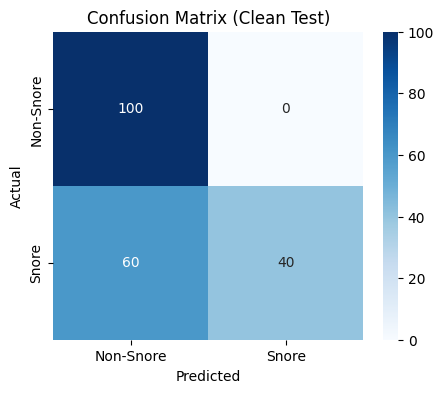

In [17]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

probs = mlp.predict(X_te_s).ravel()
preds = (probs >= 0.5).astype(int)

print(classification_report(y_te, preds, digits=4))
print('ROC-AUC:', roc_auc_score(y_te, probs))

cm = confusion_matrix(y_te, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Snore','Snore'], yticklabels=['Non-Snore','Snore'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix (Clean Test)')
plt.show()

## Evaluation — Noisy Test

In [18]:
X_te_noisy = features_from_paths(X_te_paths, add_noise=True)
X_te_noisy_s = scaler.transform(X_te_noisy)

probs_n = mlp.predict(X_te_noisy_s).ravel()
preds_n = (probs_n >= 0.5).astype(int)

print('=== Noisy Test ===')
print(classification_report(y_te, preds_n, digits=4))
print('ROC-AUC (noisy):', roc_auc_score(y_te, probs_n))

Extracting (add_noise=True): 100%|██████████| 200/200 [00:44<00:00,  4.54it/s]


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
=== Noisy Test ===
              precision    recall  f1-score   support

           0     0.8700    0.8700    0.8700       100
           1     0.8700    0.8700    0.8700       100

    accuracy                         0.8700       200
   macro avg     0.8700    0.8700    0.8700       200
weighted avg     0.8700    0.8700    0.8700       200

ROC-AUC (noisy): 0.9530000000000001


## (Optional) Save Model & Scaler to Drive

In [19]:
import joblib, os

save_dir = '/content/drive/MyDrive/snore_models'
os.makedirs(save_dir, exist_ok=True)
mlp.save(os.path.join(save_dir, 'mlp_yamnet_stat.h5'))
joblib.dump(scaler, os.path.join(save_dir, 'scaler_yamnet_stat.pkl'))
print('Saved to:', save_dir)

Saved to: /content/drive/MyDrive/snore_models


In [21]:
# ===== EXPORT FOR ANDROID (Keras 3–safe) =====
import os, numpy as np, tensorflow as tf
from keras import layers, Model, ops   # 👈 use keras.* with Keras 3
from keras.layers import Normalization
import urllib.request

# 1) Keep YAMNet TFLite for the app (feature extractor)
yamnet_tflite_path = "/content/yamnet.tflite"
if not os.path.exists(yamnet_tflite_path):
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/audioset/yamnet.tflite",
        yamnet_tflite_path
    )
print("Saved:", yamnet_tflite_path)

# 2) Wrapper that accepts embeddings [None,1024] and does mean/std with Keras ops
#    Assumes you already have `mlp` (trained head) and `scaler` from earlier cells.
feat_mean = scaler.mean_.astype("float32")      # (2048,)
feat_var  = (scaler.scale_.astype("float32") ** 2)  # variance = scale^2
norm = Normalization(mean=feat_mean, variance=feat_var)

emb_in = layers.Input(shape=(None, 1024), name="embeddings")   # (B,T,1024)

# mean over time (axis=1)
mu = layers.GlobalAveragePooling1D(name="time_mean")(emb_in)   # (B,1024)

# std over time via E[x^2] - (E[x])^2
sq = layers.Multiply(name="square")([emb_in, emb_in])          # (B,T,1024)
mean_sq = layers.GlobalAveragePooling1D(name="time_mean_sq")(sq)  # (B,1024)
mu_sq = layers.Multiply(name="mean_square")([mu, mu])             # (B,1024)
var = layers.Subtract(name="variance")([mean_sq, mu_sq])          # (B,1024)

# numeric safety: std = sqrt(max(var, eps))
eps = 1e-9
std = layers.Lambda(lambda x: ops.sqrt(ops.maximum(x, eps)),
                    name="time_std")(var)                          # (B,1024)

# concat [mean, std] -> (B,2048) then normalize and run your MLP head
feat = layers.Concatenate(axis=-1, name="feat_concat")([mu, std])  # (B,2048)
x = norm(feat)
out = mlp(x)                               # reuse your trained MLP
deploy_model = Model(emb_in, out, name="snore_from_embeddings")
deploy_model.summary()

# 3) Convert to compact TFLite (dynamic-range quantization: smallest change in app)
converter = tf.lite.TFLiteConverter.from_keras_model(deploy_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_bytes = converter.convert()

clf_tflite_path = "/content/snore_classifier_from_embeddings.tflite"
with open(clf_tflite_path, "wb") as f:
    f.write(tflite_bytes)

print("Saved:", clf_tflite_path, " size:", round(len(tflite_bytes)/1024, 1), "KB")


Saved: /content/yamnet.tflite


Model: "snore_from_embeddings"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ embeddings          │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_mean           │ (None, 1024)      │          0 │ embeddings[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ square (Multiply)   │ (None, None,      │          0 │ embeddings[0][0], │
│                     │ 1024)             │            │ embeddings[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_mean_sq        │ (None, 1024)      │          0 │ square[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean_square         │ (None, 1024)      │          0 │ time_mean[0][0],  │
│ (Multiply)          │                   │            │ time_mean[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ variance (Subtract) │ (None, 1024)      │          0 │ time_mean_sq[0][… │
│                     │                   │            │ mean_square[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_std (Lambda)   │ (None, 1024)      │          0 │ variance[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feat_concat         │ (None, 2048)      │          0 │ time_mean[0][0],  │
│ (Concatenate)       │                   │            │ time_std[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 2048)      │          0 │ feat_concat[0][0] │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 1)         │    557,569 │ normalization_1[… │
│ (Sequential)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 557,569 (2.13 MB)

 Trainable params: 557,569 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

Saved artifact at '/tmp/tmpmbdjjg4_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, None, 1024), dtype=tf.float32, name='embeddings')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138091619781328: TensorSpec(shape=(1, 2048), dtype=tf.float32, name=None)
  138091619779600: TensorSpec(shape=(1, 2048), dtype=tf.float32, name=None)
  138091863030672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138091863024912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138091863027792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138091856303440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138091856298064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138091856302864: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved: /content/snore_classifier_from_embeddings.tflite  size: 570.8 KB


## Quick Inference on a Single File

In [22]:
def predict_file(wav_path, add_noise=False):
    y = load_with_optional_noise(wav_path, add_noise=add_noise, sr=16000, target_sec=3.0)
    feat = extract_yamnet_stats_from_waveform(y)[None, :]
    feat_s = scaler.transform(feat)
    prob = mlp.predict(feat_s).ravel()[0]
    return float(prob), int(prob >= 0.5)

sample_path = X_te_paths[0]
prob, pred = predict_file(sample_path, add_noise=False)
print('File:', sample_path)
print('Snore probability:', prob)
print('Predicted class (1=Snore,0=Non):', pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
File: /content/drive/MyDrive/snore_data/Snoring Dataset/1/1_462.wav
Snore probability: 0.45658034086227417
Predicted class (1=Snore,0=Non): 0


## Environment / Versions

In [23]:
import sys, tensorflow as tf
print('Python:', sys.version)
print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

Python: 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]
TensorFlow: 2.19.0
GPU: []


In [24]:
# --- Make /content/sample.wav (16 kHz mono, 3s, PCM16) from your dataset ---

import os, random, numpy as np
import librosa
from scipy.io import wavfile

# Choose which list of paths to draw from (the code will pick the first that exists).
CANDIDATE_LIST_NAMES = ("X_te_paths", "X_val_paths", "X_tr_paths", "X_paths")
paths = None
for name in CANDIDATE_LIST_NAMES:
    if name in globals() and globals()[name]:
        paths = list(globals()[name])
        print(f"Using {name} with {len(paths)} files.")
        break
assert paths, "No dataset path list found (looked for X_te_paths / X_val_paths / X_tr_paths / X_paths)."

# --- User-tweakable knobs ---
SAMPLE_INDEX   = 0        # change this to pick a different file from the chosen list
SAMPLE_PATH    = None     # or set to an explicit path (overrides SAMPLE_INDEX)
TARGET_SR      = 16000    # 16 kHz for YAMNet
DUR_SECONDS    = 3.0
RANDOM_CROP    = False    # if True and file > 3s, take a random 3s window; else take from start
OUT_PATH       = "/content/sample.wav"

# Pick the source file
if SAMPLE_PATH is None:
    idx = max(0, min(SAMPLE_INDEX, len(paths)-1))
    src_path = paths[idx]
else:
    src_path = SAMPLE_PATH
print("Source file:", src_path)

# Load mono @ 16k
y, sr = librosa.load(src_path, sr=TARGET_SR, mono=True)

# Pad/trim to exactly 3s
target_len = int(TARGET_SR * DUR_SECONDS)
if len(y) < target_len:
    y = np.pad(y, (0, target_len - len(y)))
elif len(y) > target_len:
    if RANDOM_CROP:
        start = np.random.randint(0, len(y) - target_len + 1)
        y = y[start:start + target_len]
    else:
        y = y[:target_len]

# Normalize to prevent clipping when converting to int16
peak = float(np.max(np.abs(y))) if len(y) else 1.0
if peak < 1e-9:
    peak = 1.0
y = (0.99 * y / peak).astype(np.float32)

# Convert to PCM16 and save
y_int16 = (y * 32767.0).astype(np.int16)
wavfile.write(OUT_PATH, TARGET_SR, y_int16)

print(f"Saved {OUT_PATH}  (sr={TARGET_SR}, secs={DUR_SECONDS}, samples={len(y)}, dtype=PCM16)")

# (Optional) quick listen in Colab:
# from IPython.display import Audio, display
# display(Audio(OUT_PATH))
#
# (Optional) one-click download in Colab:
# from google.colab import files; files.download(OUT_PATH)


Using X_te_paths with 200 files.
Source file: /content/drive/MyDrive/snore_data/Snoring Dataset/1/1_462.wav
Saved /content/sample.wav  (sr=16000, secs=3.0, samples=48000, dtype=PCM16)
